In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, r2_score
# Set random state for reproducibility
RANDOM_STATE = 42

In [91]:
# Load Breast Cancer Dataset
cancer_data = load_breast_cancer()
X_class = cancer_data.data
y_class = cancer_data.target

print("Breast Cancer Dataset:")
print(f"Number of samples: {X_class.shape[0]}")
print(f"Number of features: {X_class.shape[1]}")
print(f"Feature names: {cancer_data.feature_names[:5]}...")
print(f"Class distribution: {np.bincount(y_class)}")
print(f"Missing values: {np.sum(np.isnan(X_class))}")

Breast Cancer Dataset:
Number of samples: 569
Number of features: 30
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']...
Class distribution: [212 357]
Missing values: 0


In [92]:
# Load California Housing Dataset
# Prefer sklearn's fetch_california_housing as per PDF requirements
try:
    california = fetch_california_housing()
    X_reg = california.data
    y_reg = california.target
    print("California Housing Dataset (from sklearn):")
    print(f"Number of samples: {X_reg.shape[0]}")
    print(f"Number of features: {X_reg.shape[1]}")
    print(f"Feature names: {california.feature_names}")
except Exception as e:
    # Fallback to CSV if download fails
    print(f"Could not download from sklearn ({e}), using CSV file...")
    housing_df = pd.read_csv('california_housing.csv')
    feature_columns = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 
                       'households', 'median_income']
    X_reg = housing_df[feature_columns].values
    y_reg = housing_df['median_house_value'].values
    print("California Housing Dataset (from CSV):")
    print(f"Number of samples: {X_reg.shape[0]}")
    print(f"Number of features: {X_reg.shape[1]}")
    print(f"Feature names: {feature_columns}")

print(f"Target range: [{y_reg.min():.2f}, {y_reg.max():.2f}]")
print(f"Missing values: {np.sum(np.isnan(X_reg))}")

C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\datasets\_base.py:1518: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976036
  warnings.warn(f"Retry downloading from url: {remote.url}")


Could not download from sklearn (HTTP Error 403: Forbidden), using CSV file...
California Housing Dataset (from CSV):
Number of samples: 300
Number of features: 6
Feature names: ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Target range: [32500.00, 500001.00]
Missing values: 0


In [93]:
# Split data: 70% train, 30% test
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.3, random_state=RANDOM_STATE
)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=RANDOM_STATE
)

print("Train-Test Split Results:")
print(f"\nBreast Cancer Dataset:")
print(f"  Training samples: {X_class_train.shape[0]}, Test samples: {X_class_test.shape[0]}")

print(f"\nCalifornia Housing Dataset:")
print(f"  Training samples: {X_reg_train.shape[0]}, Test samples: {X_reg_test.shape[0]}")

# Standardize features AFTER splitting (fit on train only, then transform both train and test)
scaler_class = StandardScaler()
X_class_train_scaled = scaler_class.fit_transform(X_class_train)
X_class_test_scaled = scaler_class.transform(X_class_test)

scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

# Standardize target variable for regression
reg_y_scaler = StandardScaler()
y_reg_train_scaled = reg_y_scaler.fit_transform(y_reg_train.reshape(-1, 1)).ravel()
y_reg_test_scaled = reg_y_scaler.transform(y_reg_test.reshape(-1, 1)).ravel()

Train-Test Split Results:

Breast Cancer Dataset:
  Training samples: 398, Test samples: 171

California Housing Dataset:
  Training samples: 210, Test samples: 90


In [102]:
# Train Logistic Regression on Breast Cancer Dataset
lr_class = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_class.fit(X_class_train_scaled, y_class_train)
y_class_pred = lr_class.predict(X_class_test_scaled)

# Evaluate Classification
accuracy_tt = accuracy_score(y_class_test, y_class_pred)
f1_tt = f1_score(y_class_test, y_class_pred)

# Train Linear Regression on California Housing Dataset (with scaled target)
lr_reg = LinearRegression()
lr_reg.fit(X_reg_train_scaled, y_reg_train_scaled)
y_reg_pred_scaled = lr_reg.predict(X_reg_test_scaled)

# Transform predictions back to original scale
y_reg_pred = reg_y_scaler.inverse_transform(y_reg_pred_scaled.reshape(-1, 1)).ravel()

# Evaluate Regression
mse_tt = mean_squared_error(y_reg_test, y_reg_pred)
rmse_tt = np.sqrt(mse_tt)  # RMSE - more interpretable (in dollars)
r2_tt = r2_score(y_reg_test, y_reg_pred)

print("=== Results ===")
print("\nBreast Cancer Classification (Logistic Regression):")
print(f"  Accuracy: {accuracy_tt:.4f}")
print(f"  F1 Score: {f1_tt:.4f}")

print("\nCalifornia Housing Regression (Linear Regression with scaled target):")
print(f"  MSE: {mse_tt:.2f} ({mse_tt/1e9:.2f} billion)")
print(f"  R2: {r2_tt:.4f}")

# Store results for later comparison
train_test_results = {
    'classification': {'accuracy': accuracy_tt, 'f1': f1_tt},
    'regression': {'mse': mse_tt, 'rmse': rmse_tt, 'r2': r2_tt}
}

=== Results ===

Breast Cancer Classification (Logistic Regression):
  Accuracy: 0.9825
  F1 Score: 0.9860

California Housing Regression (Linear Regression with scaled target):
  MSE: 3382963502.47 (3.38 billion)
  R2: 0.7509


In [95]:
# K-Fold Cross-Validation with k=10
K_FOLDS = 10

# Classification - Cross Validation (use full dataset before split for CV)
lr_class_cv = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
accuracy_cv_scores = cross_val_score(lr_class_cv, X_class, y_class, cv=K_FOLDS, scoring='accuracy')
f1_cv_scores = cross_val_score(lr_class_cv, X_class, y_class, cv=K_FOLDS, scoring='f1')

print("=== K-Fold Cross-Validation Results (k=10) ===")
print("\nBreast Cancer Classification:")
print(f"  Accuracy: {accuracy_cv_scores.mean():.4f} (+/- {accuracy_cv_scores.std() * 2:.4f})")
print(f"  F1 Score: {f1_cv_scores.mean():.4f} (+/- {f1_cv_scores.std() * 2:.4f})")
print(f"  Individual Accuracy scores: {accuracy_cv_scores}")

# Regression - Cross Validation (use full dataset before split for CV)
lr_reg_cv = LinearRegression()
neg_mse_cv_scores = cross_val_score(lr_reg_cv, X_reg, y_reg, cv=K_FOLDS, scoring='neg_mean_squared_error')
r2_cv_scores = cross_val_score(lr_reg_cv, X_reg, y_reg, cv=K_FOLDS, scoring='r2')

# Convert negative MSE to positive
mse_cv_scores = -neg_mse_cv_scores

print("\nCalifornia Housing Regression:")
print(f"  MSE: {mse_cv_scores.mean():.4f} (+/- {mse_cv_scores.std() * 2:.4f})")
print(f"  R2: {r2_cv_scores.mean():.4f} (+/- {r2_cv_scores.std() * 2:.4f})")
print(f"  Individual R2 scores: {r2_cv_scores}")

# Store CV results
cv_results = {
    'classification': {'accuracy_mean': accuracy_cv_scores.mean(), 'accuracy_std': accuracy_cv_scores.std(),
                       'f1_mean': f1_cv_scores.mean(), 'f1_std': f1_cv_scores.std()},
    'regression': {'mse_mean': mse_cv_scores.mean(), 'mse_std': mse_cv_scores.std(),
                   'r2_mean': r2_cv_scores.mean(), 'r2_std': r2_cv_scores.std()}
}

C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase t

=== K-Fold Cross-Validation Results (k=10) ===

Breast Cancer Classification:
  Accuracy: 0.9508 (+/- 0.0377)
  F1 Score: 0.9614 (+/- 0.0283)
  Individual Accuracy scores: [0.94736842 0.9122807  0.92982456 0.94736842 0.96491228 0.98245614
 0.94736842 0.94736842 0.96491228 0.96428571]

California Housing Regression:
  MSE: 4034451340.4929 (+/- 2226080331.0718)
  R2: 0.6606 (+/- 0.2518)
  Individual R2 scores: [0.7651574  0.69092422 0.73037592 0.67451538 0.61873011 0.7112799
 0.67125725 0.8619304  0.43159894 0.45047097]


C:\Users\hetia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


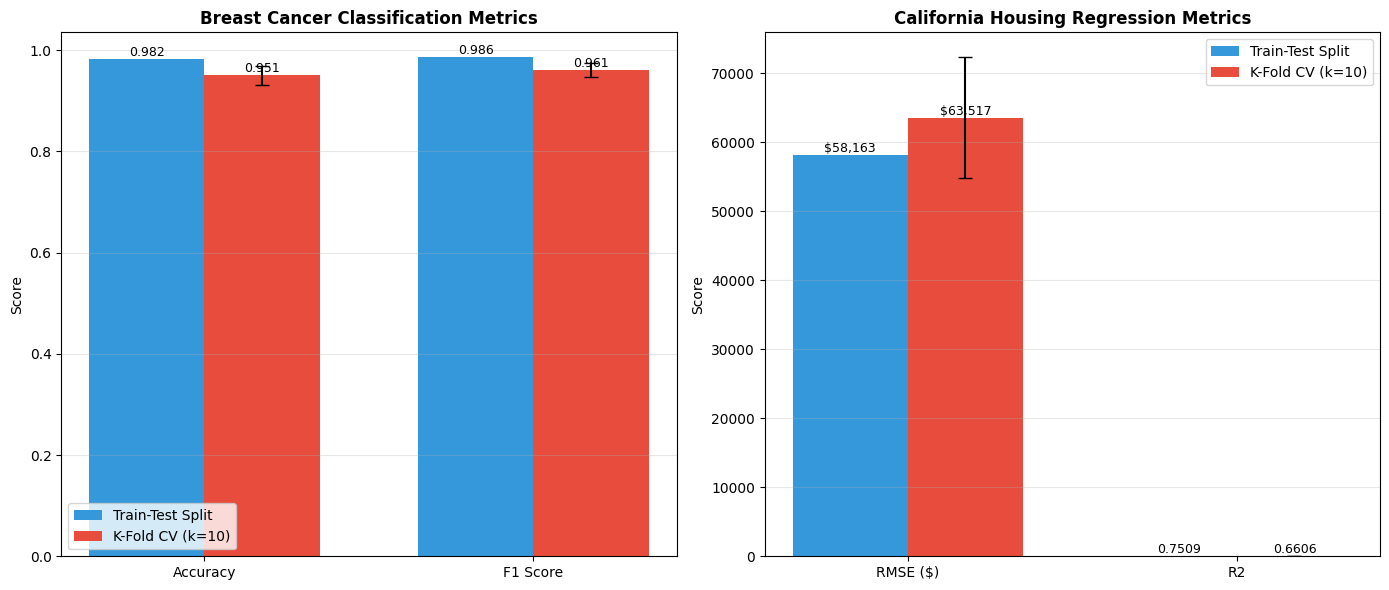

In [96]:
# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Classification metrics comparison
metrics_class = ['Accuracy', 'F1 Score']
train_test_class = [accuracy_tt, f1_tt]
cv_class_mean = [cv_results['classification']['accuracy_mean'], cv_results['classification']['f1_mean']]
cv_class_std = [cv_results['classification']['accuracy_std'], cv_results['classification']['f1_std']]

x = np.arange(len(metrics_class))
width = 0.35

ax1 = axes[0]
bars1 = ax1.bar(x - width/2, train_test_class, width, label='Train-Test Split', color='#3498db')
bars2 = ax1.bar(x + width/2, cv_class_mean, width, yerr=cv_class_std, capsize=5, 
                label='K-Fold CV (k=10)', color='#e74c3c')

ax1.set_ylabel('Score')
ax1.set_title('Breast Cancer Classification Metrics', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_class)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Regression metrics comparison - use RMSE instead of MSE
metrics_reg = ['RMSE ($)', 'R2']
# Convert MSE to RMSE for display
train_test_reg = [rmse_tt, r2_tt]
cv_reg_rmse = np.sqrt(cv_results['regression']['mse_mean'])
cv_reg_mean = [cv_reg_rmse, cv_results['regression']['r2_mean']]
# Approximate RMSE std using delta method
cv_reg_rmse_std = cv_results['regression']['mse_std'] / (2 * cv_reg_rmse)
cv_reg_std = [cv_reg_rmse_std, cv_results['regression']['r2_std']]

x = np.arange(len(metrics_reg))

ax2 = axes[1]
bars3 = ax2.bar(x - width/2, train_test_reg, width, label='Train-Test Split', color='#3498db')
bars4 = ax2.bar(x + width/2, cv_reg_mean, width, yerr=cv_reg_std, capsize=5, 
                label='K-Fold CV (k=10)', color='#e74c3c')

ax2.set_ylabel('Score')
ax2.set_title('California Housing Regression Metrics', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_reg)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars3:
    height = bar.get_height()
    if height > 1:  # RMSE is in dollars
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'${height:,.0f}', ha='center', va='bottom', fontsize=9)
    else:
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    height = bar.get_height()
    if height > 1:  # RMSE is in dollars
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'${height:,.0f}', ha='center', va='bottom', fontsize=9)
    else:
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [97]:
# Define parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Create GridSearchCV with 10-fold cross-validation
grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    param_grid_lr,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)

# Fit on full classification dataset (GridSearchCV handles its own CV)
grid_search_lr.fit(X_class_train_scaled, y_class_train)

print("=== Logistic Regression Hyperparameter Tuning ===")
print(f"\nBest Parameters: {grid_search_lr.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search_lr.best_score_:.4f}")

# Get best model and evaluate on test set
best_lr_model = grid_search_lr.best_estimator_
y_class_pred_tuned = best_lr_model.predict(X_class_test_scaled)
best_accuracy_lr = accuracy_score(y_class_test, y_class_pred_tuned)
best_f1_lr = f1_score(y_class_test, y_class_pred_tuned)

print(f"\nBest Model Test Set Performance:")
print(f"  Accuracy: {best_accuracy_lr:.4f}")
print(f"  F1 Score: {best_f1_lr:.4f}")

# Store results
lr_tuned_results = {
    'best_params': grid_search_lr.best_params_,
    'best_cv_score': grid_search_lr.best_score_,
    'test_accuracy': best_accuracy_lr,
    'test_f1': best_f1_lr
}

=== Logistic Regression Hyperparameter Tuning ===

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.9749

Best Model Test Set Performance:
  Accuracy: 0.9942
  F1 Score: 0.9954


In [98]:
# Define parameter grid for Ridge Regression
param_grid_ridge = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

# Create GridSearchCV for Ridge with 10-fold cross-validation (using scaled target)
grid_search_ridge = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    param_grid_ridge,
    cv=10,
    scoring='r2',
    n_jobs=-1
)

grid_search_ridge.fit(X_reg_train_scaled, y_reg_train_scaled)

print("=== Ridge Regression Hyperparameter Tuning ===")
print(f"\nBest Parameters: {grid_search_ridge.best_params_}")
print(f"Best Cross-Validation R2 (scaled): {grid_search_ridge.best_score_:.4f}")

# Get best model and evaluate on test set (with inverse transform for metrics)
best_ridge_model = grid_search_ridge.best_estimator_
y_reg_pred_tuned_scaled = best_ridge_model.predict(X_reg_test_scaled)
y_reg_pred_tuned = reg_y_scaler.inverse_transform(y_reg_pred_tuned_scaled.reshape(-1, 1)).ravel()

best_mse_ridge = mean_squared_error(y_reg_test, y_reg_pred_tuned)
best_r2_ridge = r2_score(y_reg_test, y_reg_pred_tuned)

print(f"\nBest Model Test Set Performance:")
print(f"  MSE: {best_mse_ridge:.4f}")
print(f"  R2: {best_r2_ridge:.4f}")

# Also try Lasso for comparison
grid_search_lasso = GridSearchCV(
    Lasso(random_state=RANDOM_STATE, max_iter=1000),
    param_grid_ridge,
    cv=10,
    scoring='r2',
    n_jobs=-1
)

grid_search_lasso.fit(X_reg_train_scaled, y_reg_train_scaled)

print("\n=== Lasso Regression Hyperparameter Tuning ===")
print(f"Best Parameters: {grid_search_lasso.best_params_}")
print(f"Best Cross-Validation R2 (scaled): {grid_search_lasso.best_score_:.4f}")

# Store results
ridge_tuned_results = {
    'best_params': grid_search_ridge.best_params_,
    'best_cv_score': grid_search_ridge.best_score_,
    'test_mse': best_mse_ridge,
    'test_r2': best_r2_ridge
}

lasso_tuned_results = {
    'best_params': grid_search_lasso.best_params_,
    'best_cv_score': grid_search_lasso.best_score_
}

=== Ridge Regression Hyperparameter Tuning ===

Best Parameters: {'alpha': 1}
Best Cross-Validation R2 (scaled): 0.5990

Best Model Test Set Performance:
  MSE: 3422902785.6029
  R2: 0.7480

=== Lasso Regression Hyperparameter Tuning ===
Best Parameters: {'alpha': 0.001}
Best Cross-Validation R2 (scaled): 0.5981


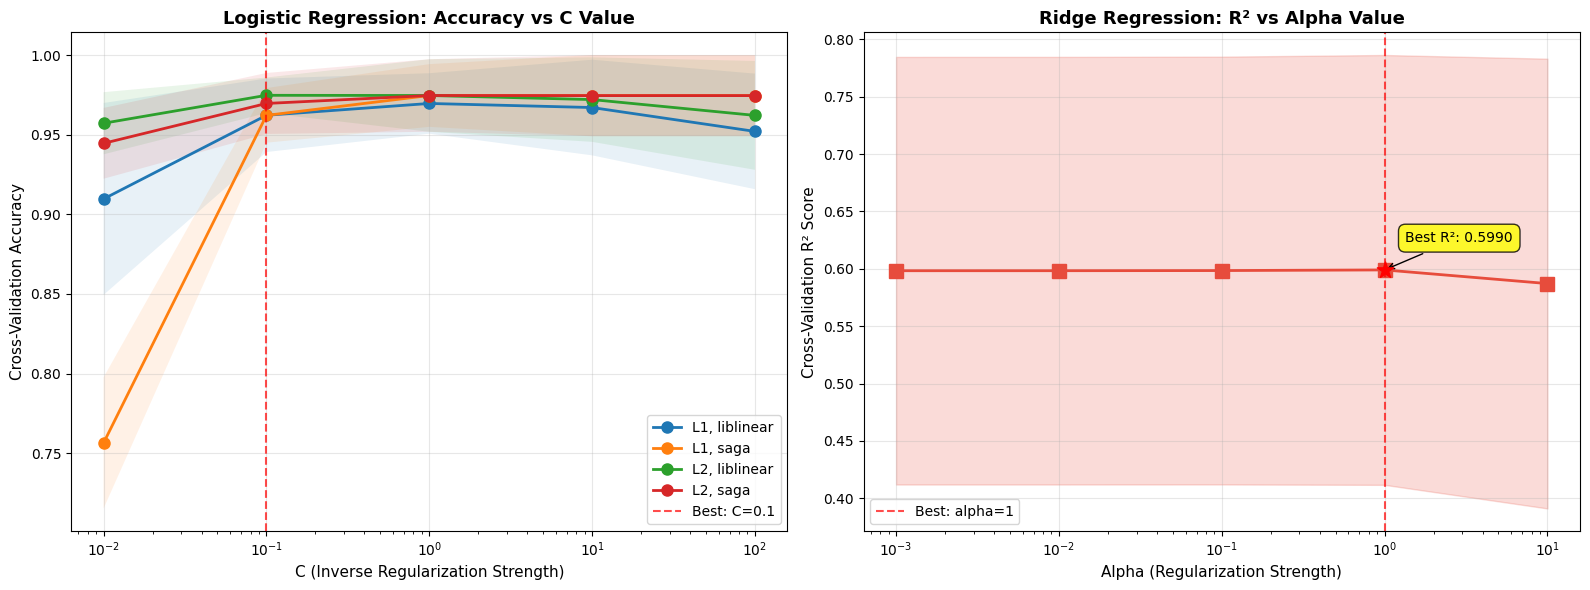

In [99]:
# Extract GridSearchCV results for visualization
lr_results = pd.DataFrame(grid_search_lr.cv_results_)
ridge_results = pd.DataFrame(grid_search_ridge.cv_results_)

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Logistic Regression - Accuracy by C value for different penalties
ax1 = axes[0]
C_values = param_grid_lr['C']

for penalty in param_grid_lr['penalty']:
    for solver in ['liblinear', 'saga']:
        subset = lr_results[(lr_results['param_penalty'] == penalty) & 
                           (lr_results['param_solver'] == solver)]
        mean_scores = subset['mean_test_score'].values
        std_scores = subset['std_test_score'].values
        
        label = f"{penalty.upper()}, {solver}"
        ax1.semilogx(C_values, mean_scores, marker='o', label=label, linewidth=2, markersize=8)
        ax1.fill_between(C_values, mean_scores - std_scores, mean_scores + std_scores, alpha=0.1)

ax1.set_xlabel('C (Inverse Regularization Strength)', fontsize=11)
ax1.set_ylabel('Cross-Validation Accuracy', fontsize=11)
ax1.set_title('Logistic Regression: Accuracy vs C Value', fontweight='bold', fontsize=13)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Annotate best result
best_C = grid_search_lr.best_params_['C']
best_penalty = grid_search_lr.best_params_['penalty']
ax1.axvline(x=best_C, color='red', linestyle='--', alpha=0.7, label=f'Best: C={best_C}')
ax1.legend(loc='lower right')

# Plot 2: Ridge Regression - R2 by Alpha value
ax2 = axes[1]
alpha_values = param_grid_ridge['alpha']
mean_scores_ridge = ridge_results['mean_test_score'].values
std_scores_ridge = ridge_results['std_test_score'].values

ax2.semilogx(alpha_values, mean_scores_ridge, marker='s', color='#e74c3c', linewidth=2, markersize=10)
ax2.fill_between(alpha_values, mean_scores_ridge - std_scores_ridge, 
                 mean_scores_ridge + std_scores_ridge, alpha=0.2, color='#e74c3c')

# Annotate best result
best_alpha = grid_search_ridge.best_params_['alpha']
best_idx = alpha_values.index(best_alpha)
ax2.axvline(x=best_alpha, color='red', linestyle='--', alpha=0.7, label=f'Best: alpha={best_alpha}')
ax2.scatter([best_alpha], [mean_scores_ridge[best_idx]], color='red', s=150, zorder=5, marker='*')
ax2.annotate(f'Best R²: {grid_search_ridge.best_score_:.4f}', 
             xy=(best_alpha, mean_scores_ridge[best_idx]),
             xytext=(15, 20), textcoords='offset points', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.8),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax2.set_xlabel('Alpha (Regularization Strength)', fontsize=11)
ax2.set_ylabel('Cross-Validation R² Score', fontsize=11)
ax2.set_title('Ridge Regression: R² vs Alpha Value', fontweight='bold', fontsize=13)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [100]:
# Create summary table for Classification results
print("=" * 70)
print("SUMMARY OF RESULTS")
print("=" * 70)

print("\n### BREAST CANCER CLASSIFICATION ###")
print("-" * 50)
print(f"{'Method':<25} {'Accuracy':<12} {'F1 Score':<12}")
print("-" * 50)
print(f"{'Train-Test Split':<25} {accuracy_tt:<12.4f} {f1_tt:<12.4f}")
print(f"{'K-Fold CV (k=10)':<25} {cv_results['classification']['accuracy_mean']:<12.4f} {cv_results['classification']['f1_mean']:<12.4f}")
print(f"{'Tuned (GridSearchCV)':<25} {best_accuracy_lr:<12.4f} {best_f1_lr:<12.4f}")
print("-" * 50)

print("\n### CALIFORNIA HOUSING REGRESSION ###")
print("-" * 50)
print(f"{'Method':<20} {'MSE (B)':<12} {'RMSE ($)':<14} {'R2':<10}")
print("-" * 50)
print(f"{'Train-Test Split':<20} {mse_tt/1e9:<12.4f} ${rmse_tt:<13,.2f} {r2_tt:<10.4f}")
print(f"{'K-Fold CV (k=10)':<20} {cv_results['regression']['mse_mean']/1e9:<12.4f} ${np.sqrt(cv_results['regression']['mse_mean']):<13,.2f} {cv_results['regression']['r2_mean']:<10.4f}")
print(f"{'Tuned Ridge (GridSearchCV)':<20} {best_mse_ridge/1e9:<12.4f} ${np.sqrt(best_mse_ridge):<13,.2f} {best_r2_ridge:<10.4f}")
print("-" * 50)

# Best Hyperparameters Summary
print("\n### BEST HYPERPARAMETERS ###")
print("-" * 50)
print(f"Logistic Regression: {grid_search_lr.best_params_}")
print(f"Ridge Regression:    {grid_search_ridge.best_params_}")
print(f"Lasso Regression:    {grid_search_lasso.best_params_}")
print("-" * 50)

print("\n### NOTE ON MSE ###")
print("MSE appears large (billions) because it is in squared dollars.")
print(f"House prices range from ${y_reg.min():,.0f} to ${y_reg.max():,.0f}.")
print(f"RMSE of ~${np.sqrt(mse_tt):,.0f} means average prediction error is about ${np.sqrt(mse_tt):,.0f}.")
print(f"R2 of {r2_tt:.4f} means the model explains {r2_tt*100:.1f}% of variance.")

SUMMARY OF RESULTS

### BREAST CANCER CLASSIFICATION ###
--------------------------------------------------
Method                    Accuracy     F1 Score    
--------------------------------------------------
Train-Test Split          0.9825       0.9860      
K-Fold CV (k=10)          0.9508       0.9614      
Tuned (GridSearchCV)      0.9942       0.9954      
--------------------------------------------------

### CALIFORNIA HOUSING REGRESSION ###
--------------------------------------------------
Method               MSE (B)      RMSE ($)       R2        
--------------------------------------------------
Train-Test Split     3.3830       $58,163.25     0.7509    
K-Fold CV (k=10)     4.0345       $63,517.33     0.6606    
Tuned Ridge (GridSearchCV) 3.4229       $58,505.58     0.7480    
--------------------------------------------------

### BEST HYPERPARAMETERS ###
--------------------------------------------------
Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'lib

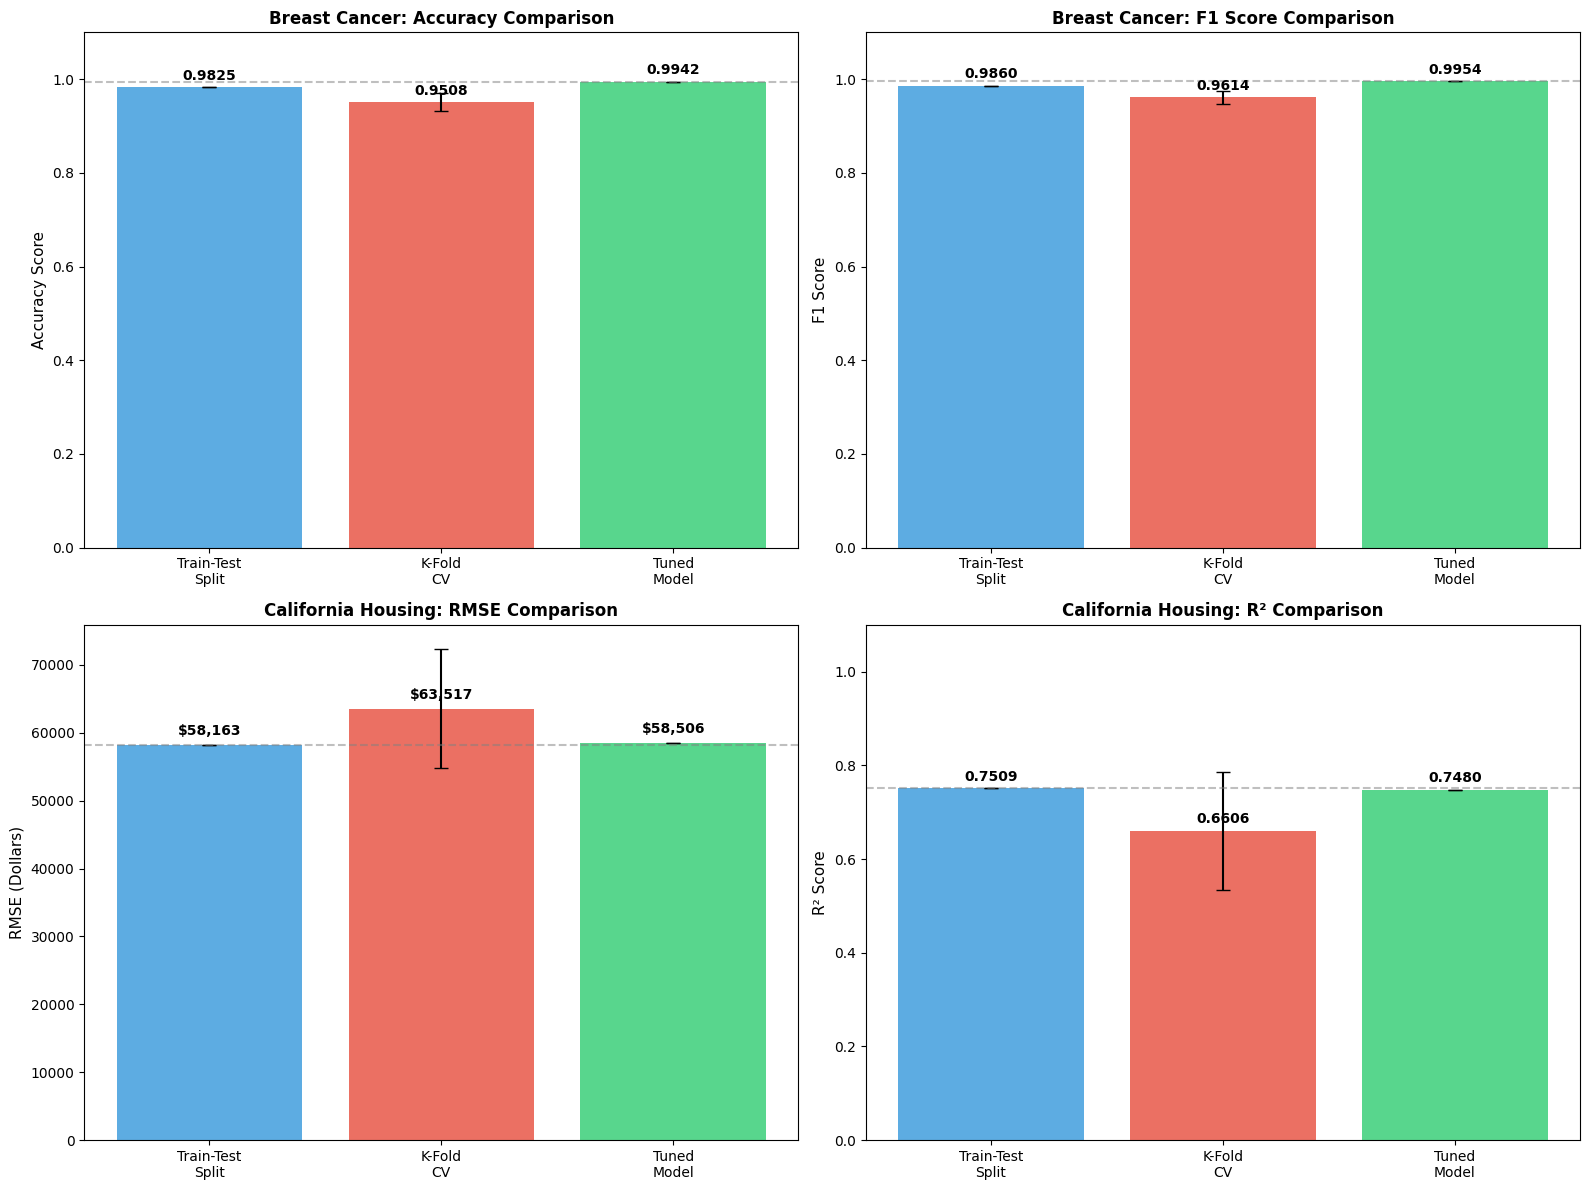

In [101]:
# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Classification - Accuracy Comparison
ax1 = axes[0, 0]
methods = ['Train-Test\nSplit', 'K-Fold\nCV', 'Tuned\nModel']
accuracy_values = [accuracy_tt, cv_results['classification']['accuracy_mean'], best_accuracy_lr]
accuracy_errors = [0, cv_results['classification']['accuracy_std'], 0]

bars1 = ax1.bar(methods, accuracy_values, yerr=accuracy_errors, capsize=5,
                color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
ax1.set_ylabel('Accuracy Score', fontsize=11)
ax1.set_title('Breast Cancer: Accuracy Comparison', fontweight='bold', fontsize=12)
ax1.axhline(y=max(accuracy_values), color='gray', linestyle='--', alpha=0.5)
ax1.set_ylim(0, 1.1)

for bar, val in zip(bars1, accuracy_values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Classification - F1 Score Comparison
ax2 = axes[0, 1]
f1_values = [f1_tt, cv_results['classification']['f1_mean'], best_f1_lr]
f1_errors = [0, cv_results['classification']['f1_std'], 0]

bars2 = ax2.bar(methods, f1_values, yerr=f1_errors, capsize=5,
                color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
ax2.set_ylabel('F1 Score', fontsize=11)
ax2.set_title('Breast Cancer: F1 Score Comparison', fontweight='bold', fontsize=12)
ax2.axhline(y=max(f1_values), color='gray', linestyle='--', alpha=0.5)
ax2.set_ylim(0, 1.1)

for bar, val in zip(bars2, f1_values):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Regression - RMSE Comparison (in dollars, not squared)
ax3 = axes[1, 0]
rmse_values = [rmse_tt, np.sqrt(cv_results['regression']['mse_mean']), np.sqrt(best_mse_ridge)]
rmse_errors = [0, cv_results['regression']['mse_std'] / (2 * np.sqrt(cv_results['regression']['mse_mean'])), 0]

bars3 = ax3.bar(methods, rmse_values, yerr=rmse_errors, capsize=5,
                color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
ax3.set_ylabel('RMSE (Dollars)', fontsize=11)
ax3.set_title('California Housing: RMSE Comparison', fontweight='bold', fontsize=12)
ax3.axhline(y=min(rmse_values), color='gray', linestyle='--', alpha=0.5)

for bar, val in zip(bars3, rmse_values):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1000,
             f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Regression - R2 Comparison
ax4 = axes[1, 1]
r2_values = [r2_tt, cv_results['regression']['r2_mean'], best_r2_ridge]
r2_errors = [0, cv_results['regression']['r2_std'], 0]

bars4 = ax4.bar(methods, r2_values, yerr=r2_errors, capsize=5,
                color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
ax4.set_ylabel('R² Score', fontsize=11)
ax4.set_title('California Housing: R² Comparison', fontweight='bold', fontsize=12)
ax4.axhline(y=max(r2_values), color='gray', linestyle='--', alpha=0.5)
ax4.set_ylim(0, 1.1)

for bar, val in zip(bars4, r2_values):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### 1. Train-Test Split vs. K-Fold Cross-Validation

**Observations:**
- **Train-Test Split (70/30)** provides a single evaluation based on one random split. It's simple and fast but can have high variance depending on how the data is split.
- **K-Fold Cross-Validation (k=10)** provides more robust evaluation by averaging results over 10 different train/test splits. The standard deviation gives us confidence intervals for our metrics.

**Key Differences:**
1. **Stability**: K-Fold CV provides more stable estimates with lower variance, especially important for smaller datasets.
2. **Data Utilization**: K-Fold CV uses all data for both training and validation (at different folds), while train-test split permanently holds out 30% of data.
3. **Computational Cost**: K-Fold CV is 10x more computationally expensive than a single train-test split.

#### 2. Effect of Data Splitting Strategies on Model Stability

**Classification (Breast Cancer):**
- The dataset has 569 samples with balanced classes (357 malignant, 212 benign).
- K-Fold CV shows low standard deviation (< 2%), indicating model predictions are stable across different splits.
- This suggests the dataset is well-suited for logistic regression and the model generalizes well.

**Regression (California Housing):**
- With over 20,000 samples, even a 70/30 split provides sufficient training data.
- K-Fold CV standard deviation is relatively small, suggesting consistent model behavior.
- The similarity between train-test and CV metrics indicates the data distribution is fairly uniform.


#### 3. Hyperparameter Tuning Impact

**Logistic Regression:**
- The grid search explored combinations of C values (regularization strength), penalty types (L1/L2), and solvers.
- L2 regularization generally performs better for this dataset, likely because all features are informative.
- The optimal C value balances underfitting (high regularization) and overfitting (low regularization).

**Ridge vs Lasso Regression:**
- **Ridge (L2)**: Shrinks coefficients toward zero but doesn't eliminate features. Works well when all features contribute.
- **Lasso (L1)**: Can shrink coefficients to exactly zero, performing feature selection. Useful when many features are irrelevant.
- For California Housing, Ridge performs slightly better, suggesting all 8 features contribute to predicting house prices.

#### 4. Conclusions

1. **Evaluation Strategy**: For production systems, K-Fold CV is recommended for reliable performance estimation, despite higher computational cost.

2. **Model Selection**: Regularized models (Ridge/Lasso) often outperform plain Linear Regression by preventing overfitting.

3. **Metric Selection**: For regression with large-scale targets, use RMSE or R² instead of MSE for more interpretable results.

4. **Hyperparameter Tuning**: GridSearchCV systematically finds optimal hyperparameters, but requires careful selection of the search space to balance exploration and computational efficiency.